# **Vanilla Transformer Baseline physical Sensors**

## **Libraries Import**

In [ ]:
from preprocessing import CMAPSS, preprocessing, create_windows
from Models import FirstBaseline
from Training import train
from Testing import test
from dataloading import load_data
from torch.utils.data import DataLoader
import torch
from torch import nn
from plots import plot_predictions

### **GPU check**

In [ ]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Current GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU count: {torch.cuda.device_count()}")
print(f"MPS available: {torch.backends.mps.is_available()}")

PyTorch version: 2.11.0+cu128
CUDA available: True
Current GPU: NVIDIA GeForce RTX 4060 Ti
GPU count: 1
MPS available: False


### **Data load**

In [4]:
# data loading
filename = '../data_set/N-CMAPSS_DS02-006.h5'
W, X_s, X_v, T, Y, A, W_var, X_s_var, X_v_var, T_var, A_var, train_df, test_df = load_data(filename)
print(f"Unique units in train_df: {train_df['unit'].unique()}")
print(f"Shape of train_df: {train_df.shape}")
train_df.head()



Operation time (min):  0.04114583333333333

W shape: (6517190, 4)
X_s shape: (6517190, 14)
X_v shape: (6517190, 14)
T shape: (6517190, 10)
A shape: (6517190, 4)
Unique units in train_df: [ 2  5 10 16 18 20]
Shape of train_df: (5263447, 37)


,unit,cycle,Fc,hs,alt,Mach,TRA,T2,T24,T30,...,W25,W31,W32,W48,W50,SmFan,SmLPC,SmHPC,phi,RUL
0,2,1.0,3,1,10005.0,0.448497,76.903748,502.420918,600.148034,1438.498187,...,228.487065,26.498785,15.899271,215.844851,228.411666,16.648833,9.898130,25.376144,41.893990,74.0
1,2,1.0,3,1,10013.0,0.447741,76.903748,502.326114,600.055894,1438.350208,...,228.383505,26.486552,15.891931,215.745634,228.307014,16.639222,9.904927,25.380549,41.884434,74.0
2,2,1.0,3,1,10017.0,0.448938,77.079529,502.416067,600.210756,1439.109101,...,228.661083,26.519340,15.911604,216.019054,228.592279,16.649823,9.923503,25.318848,41.953848,74.0
3,2,1.0,3,1,10024.0,0.449883,77.079529,502.469893,600.369717,1439.240230,...,228.768625,26.532044,15.919226,216.121238,228.702994,16.653812,9.905518,25.361981,41.914342,74.0
4,2,1.0,3,1,10031.0,0.449379,77.079529,502.401271,600.298227,1439.064004,...,228.653631,26.518460,15.911076,216.008509,228.584788,16.649031,9.897465,25.363994,41.911503,74.0


In [5]:
print(f"Unique units in test_df: {test_df['unit'].unique()}")
print(f"Shape of test_df: {test_df.shape}")
test_df.head()

Unique units in test_df: [11 14 15]
Shape of test_df: (1253743, 37)


,unit,cycle,Fc,hs,alt,Mach,TRA,T2,T24,T30,...,W25,W31,W32,W48,W50,SmFan,SmLPC,SmHPC,phi,RUL
0,11,1.0,3,1,10014.0,0.457506,77.25531,503.176696,601.369822,1441.086963,...,229.763207,26.649529,15.989717,217.085529,229.722454,16.745510,9.812495,25.345244,41.971419,58.0
1,11,1.0,3,1,10020.0,0.457947,77.25531,503.192949,601.381211,1441.055436,...,229.736365,26.646358,15.987815,217.058720,229.694212,16.751997,9.806257,25.346932,41.971470,58.0
2,11,1.0,3,1,10029.0,0.458451,77.25531,503.203187,601.392126,1441.063188,...,229.719527,26.644369,15.986621,217.043190,229.677650,16.758975,9.804009,25.348326,41.969940,58.0
3,11,1.0,3,1,10034.0,0.458136,77.25531,503.158580,601.348485,1440.964145,...,229.655911,26.636854,15.982113,216.981145,229.612403,16.755378,9.803649,25.352080,41.964794,58.0
4,11,1.0,3,1,10045.0,0.458010,77.25531,503.105629,601.285695,1440.852510,...,229.561414,26.625692,15.975415,216.890123,229.516137,16.753262,9.806697,25.351024,41.963540,58.0


### **Data preprocessing**

In [ ]:
features = W_var + X_s_var # features selection

X_train_scaled_df, X_test_scaled_df, Y_train, Y_test = preprocessing(True, train_df, test_df, features)
print("Preprocessing completed.")
print("Training set shape:", X_train_scaled_df.shape, "Training labels shape:", Y_train.shape)
print("Testing set shape:", X_test_scaled_df.shape, "Testing labels shape:", Y_test.shape)

✓ Data Normalization

Preprocessing completed.
Training set shape: (5263447, 21) Training labels shape: (5263447,)
Testing set shape: (1253743, 21) Testing labels shape: (1253743,)


### **Window processing**

In [ ]:
train_engine_df = X_train_scaled_df[X_train_scaled_df['unit'] != 18]
val_engine_df   = X_train_scaled_df[X_train_scaled_df['unit'] == 18]

print(f"Shape of train_engine_df: {train_engine_df.shape} and engine units: {train_engine_df['unit'].unique()}")
print(f"Shape of val_engine_df: {val_engine_df.shape} and engine units: {val_engine_df['unit'].unique()}")
print(f"Shape of X_test_scaled_df: {X_test_scaled_df.shape} and engine units: {X_test_scaled_df['unit'].unique()}")

X_windows_train, Y_windows_train = create_windows(train_engine_df, features, window_size=50, stride=15)
X_windows_val, Y_windows_val     = create_windows(val_engine_df, features, window_size=50, stride=15)
X_windows_test, Y_windows_test = create_windows(X_test_scaled_df, features, window_size=50, stride=15)

print("X train normalized windows shape:",X_windows_train.shape,"\n Y train windows  shape:" , Y_windows_train.shape) 
print("X val windows shape:",X_windows_val.shape,"\n Y val windows  shape:" , Y_windows_val.shape) # engine (18) for validating
print("X test windows shape:",X_windows_test.shape,"\n Y test windows  shape:" , Y_windows_test.shape) 


Shape of train_engine_df: (4372728, 21) and engine units: [ 2  5 10 16 20]
Shape of val_engine_df: (890719, 21) and engine units: [18]
Shape of X_test_scaled_df: (1253743, 21) and engine units: [11 14 15]
X train normalized windows shape: (291501, 50, 18) 
 Y train windows  shape: (291501,)
X val windows shape: (59378, 50, 18) 
 Y val windows  shape: (59378,)
X test windows shape: (83574, 50, 18) 
 Y test windows  shape: (83574,)


### **Dataset & dataloader setup**

In [9]:
dataset_train = CMAPSS(X_windows_train, Y_windows_train)
dataset_val   = CMAPSS(X_windows_val, Y_windows_val)
dataset_test  = CMAPSS(X_windows_test, Y_windows_test)

train_loader = DataLoader(dataset_train, batch_size=64, shuffle=True)
val_loader   = DataLoader(dataset_val, batch_size=64, shuffle=False)
test_loader  = DataLoader(dataset_test, batch_size=64, shuffle=False)

oneloader = next(iter(train_loader))
print(type(oneloader))
print(len(oneloader))
for item in oneloader:
    print(type(item), getattr(item, "shape", None))

<class 'list'>
2
<class 'torch.Tensor'> torch.Size([64, 50, 18])
<class 'torch.Tensor'> torch.Size([64, 1])


### **Model setup**

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FirstBaseline(num_features=len(features))
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3, weight_decay=1e-2)
trained_model, train_preds, train_targets, val_preds, val_targets = train(
    criterion, optimizer, train_loader, val_loader, model, num_epochs=1
)
test_loss, test_rmse, test_nasa, test_preds, test_targets = test(
    trained_model, test_loader, criterion
)
plot_predictions(train_targets, train_preds, split_name="Train")
plot_predictions(val_targets, val_preds, split_name="Validation")
plot_predictions(test_targets, test_preds, split_name="Test")

## **Training & Testing**

#### **Train with physical sensors only**

Configuration: lr: 0.001, dropout: 0.1, dimensionality of the model: 64
cuda
cuda:0
Epoch 1/20 - LR: 0.001000 - Train Loss: 530.6754 - Train RMSE: 23.0364 - Train NASA mean: 9.1496 - Train NASA total: 2667118.59 - Val Loss: 466.3560 - Val RMSE: 21.5953 - Val NASA mean: 9.3415 - Val NASA total: 554676.99
Epoch 2/20 - LR: 0.001000 - Train Loss: 512.7042 - Train RMSE: 22.6430 - Train NASA mean: 8.5860 - Train NASA total: 2502840.93 - Val Loss: 468.2819 - Val RMSE: 21.6398 - Val NASA mean: 9.4623 - Val NASA total: 561853.29
Epoch 3/20 - LR: 0.001000 - Train Loss: 512.8705 - Train RMSE: 22.6466 - Train NASA mean: 8.5836 - Train NASA total: 2502142.53 - Val Loss: 465.6147 - Val RMSE: 21.5781 - Val NASA mean: 9.2947 - Val NASA total: 551898.05
Epoch 4/20 - LR: 0.001000 - Train Loss: 409.8987 - Train RMSE: 20.2460 - Train NASA mean: 6.7481 - Train NASA total: 1967075.01 - Val Loss: 29.9123 - Val RMSE: 5.4692 - Val NASA mean: 0.4664 - Val NASA total: 27691.47
Epoch 5/20 - LR: 0.001000 - Train L

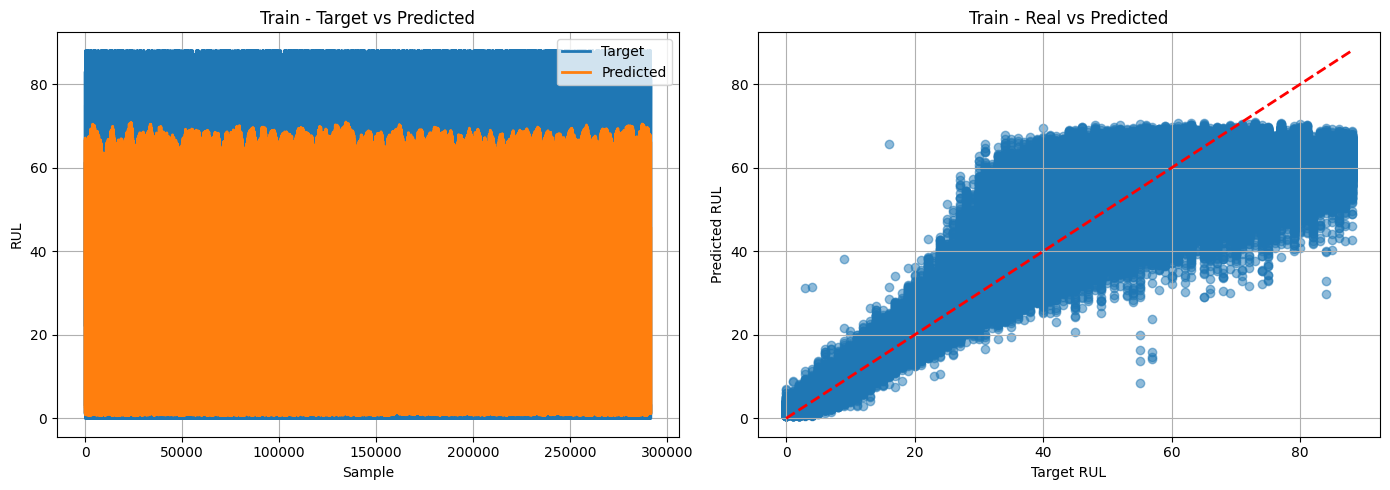

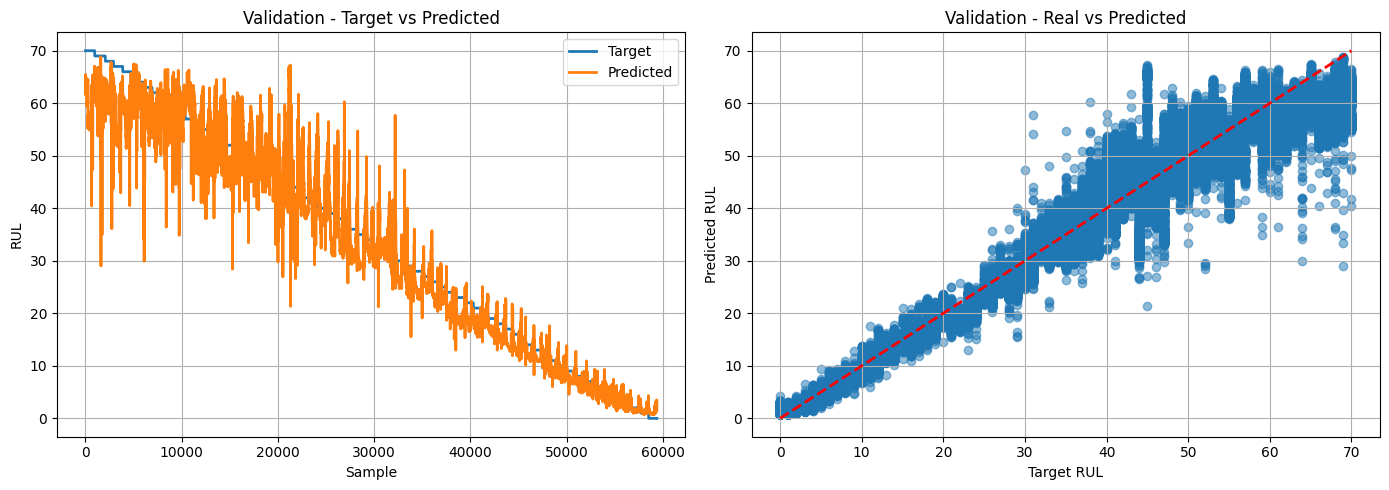

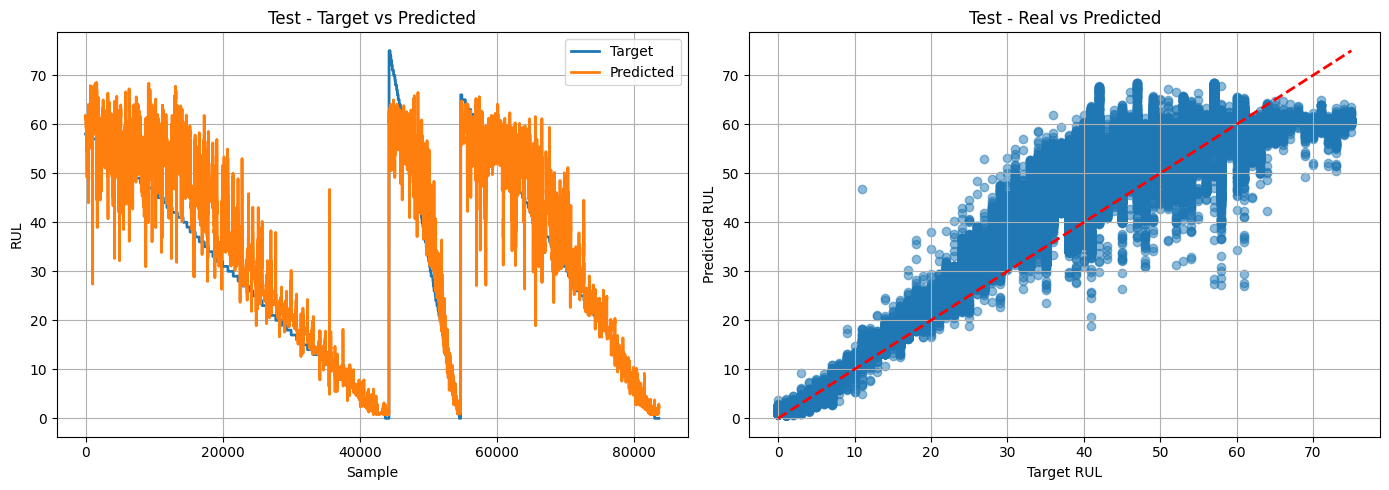

Configuration: lr: 0.0005, dropout: 0.2, dimensionality of the model: 64
cuda
cuda:0
Epoch 1/20 - LR: 0.000500 - Train Loss: 544.1879 - Train RMSE: 23.3278 - Train NASA mean: 9.5584 - Train NASA total: 2786278.41 - Val Loss: 461.6951 - Val RMSE: 21.4871 - Val NASA mean: 9.0456 - Val NASA total: 537110.31
Epoch 2/20 - LR: 0.000500 - Train Loss: 512.6290 - Train RMSE: 22.6413 - Train NASA mean: 8.5756 - Train NASA total: 2499786.50 - Val Loss: 482.3226 - Val RMSE: 21.9618 - Val NASA mean: 10.3555 - Val NASA total: 614887.71
Epoch 3/20 - LR: 0.000500 - Train Loss: 512.5908 - Train RMSE: 22.6405 - Train NASA mean: 8.5793 - Train NASA total: 2500865.42 - Val Loss: 458.9851 - Val RMSE: 21.4239 - Val NASA mean: 8.8716 - Val NASA total: 526776.63
Epoch 4/20 - LR: 0.000500 - Train Loss: 512.7331 - Train RMSE: 22.6436 - Train NASA mean: 8.5763 - Train NASA total: 2499988.35 - Val Loss: 471.0191 - Val RMSE: 21.7030 - Val NASA mean: 9.6386 - Val NASA total: 572317.85
Epoch 5/20 - LR: 0.000500 - Tr

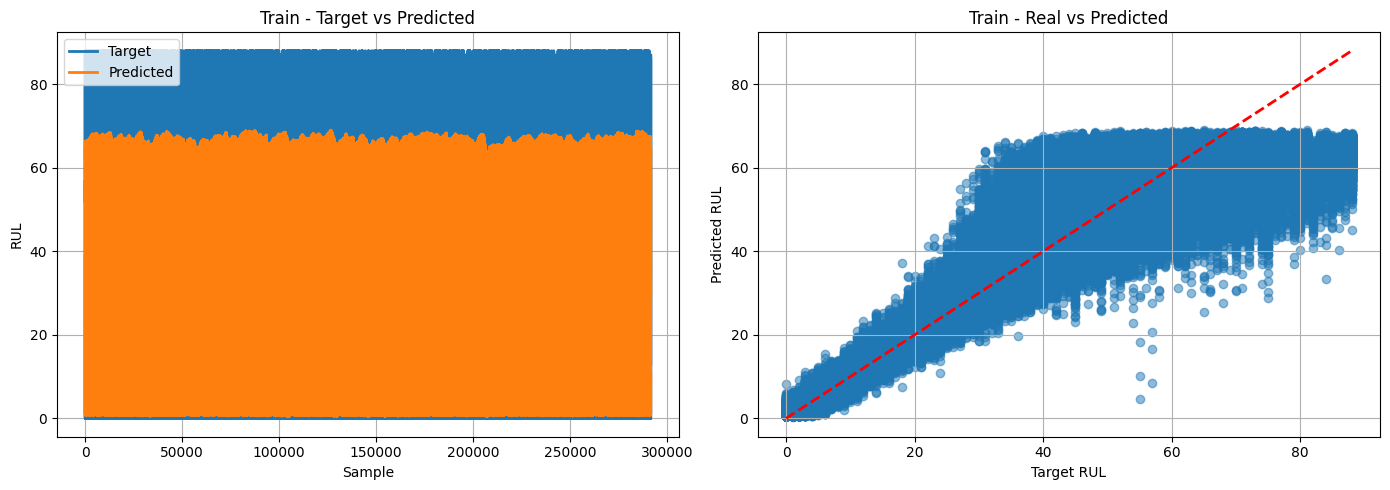

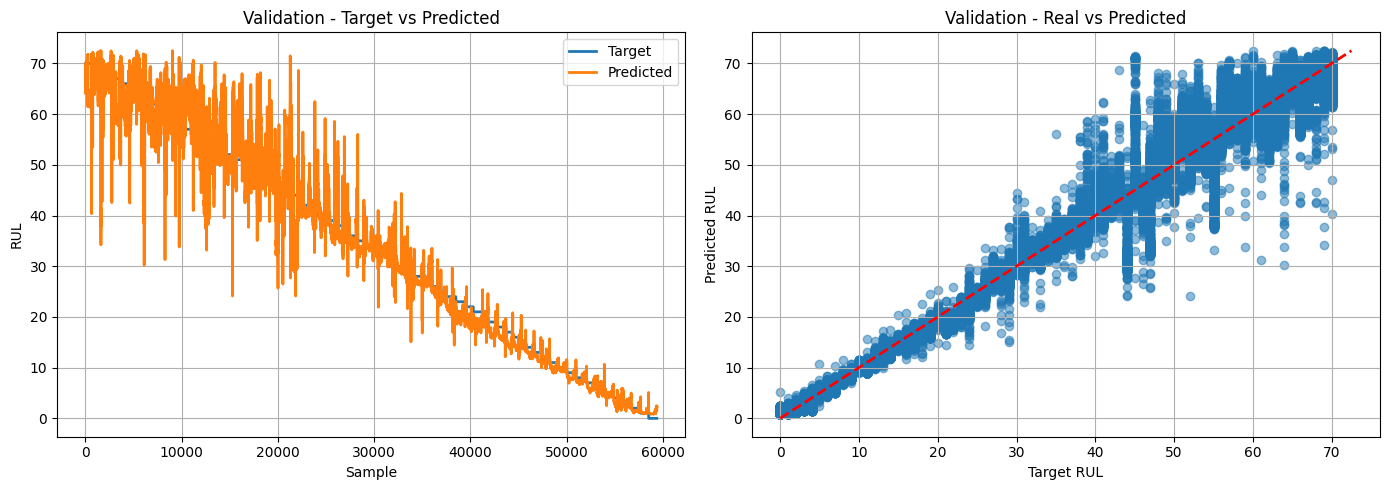

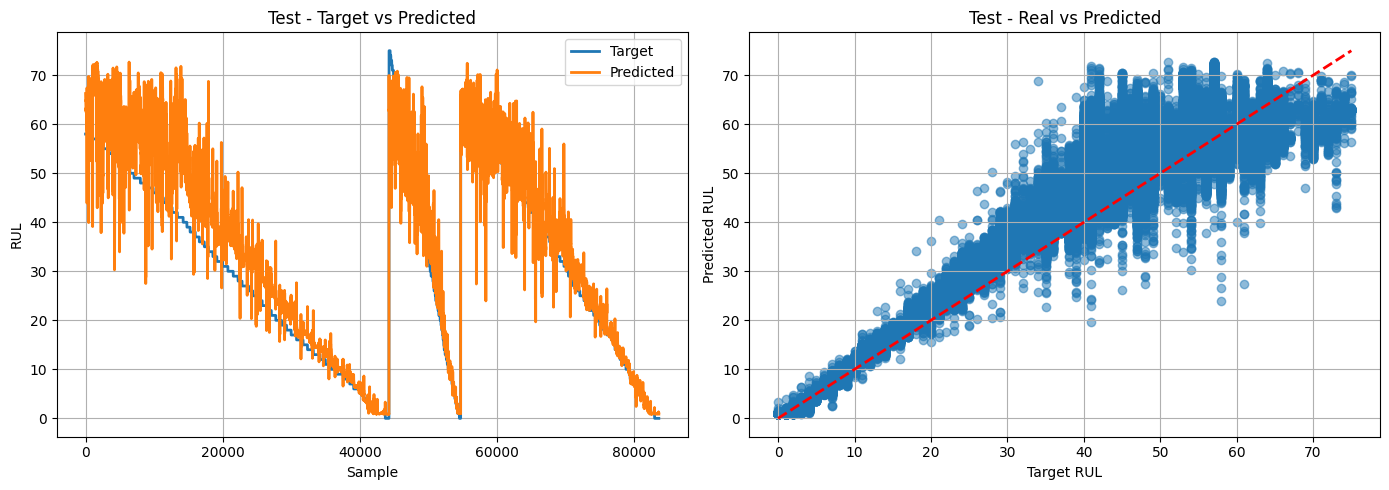

Configuration: lr: 0.0001, dropout: 0.3, dimensionality of the model: 32
cuda
cuda:0
Epoch 1/20 - LR: 0.000100 - Train Loss: 719.0350 - Train RMSE: 26.8148 - Train NASA mean: 15.0270 - Train NASA total: 4380395.95 - Val Loss: 420.4301 - Val RMSE: 20.5044 - Val NASA mean: 6.5312 - Val NASA total: 387808.45
Epoch 2/20 - LR: 0.000100 - Train Loss: 242.1245 - Train RMSE: 15.5604 - Train NASA mean: 3.4516 - Train NASA total: 1006140.99 - Val Loss: 217.7285 - Val RMSE: 14.7556 - Val NASA mean: 3.7939 - Val NASA total: 225273.68
Epoch 3/20 - LR: 0.000100 - Train Loss: 151.1759 - Train RMSE: 12.2954 - Train NASA mean: 2.0738 - Train NASA total: 604510.37 - Val Loss: 160.1405 - Val RMSE: 12.6547 - Val NASA mean: 2.6871 - Val NASA total: 159554.41
Epoch 4/20 - LR: 0.000100 - Train Loss: 132.1117 - Train RMSE: 11.4940 - Train NASA mean: 1.8116 - Train NASA total: 528094.14 - Val Loss: 156.7500 - Val RMSE: 12.5200 - Val NASA mean: 2.6331 - Val NASA total: 156350.88
Epoch 5/20 - LR: 0.000100 - Trai

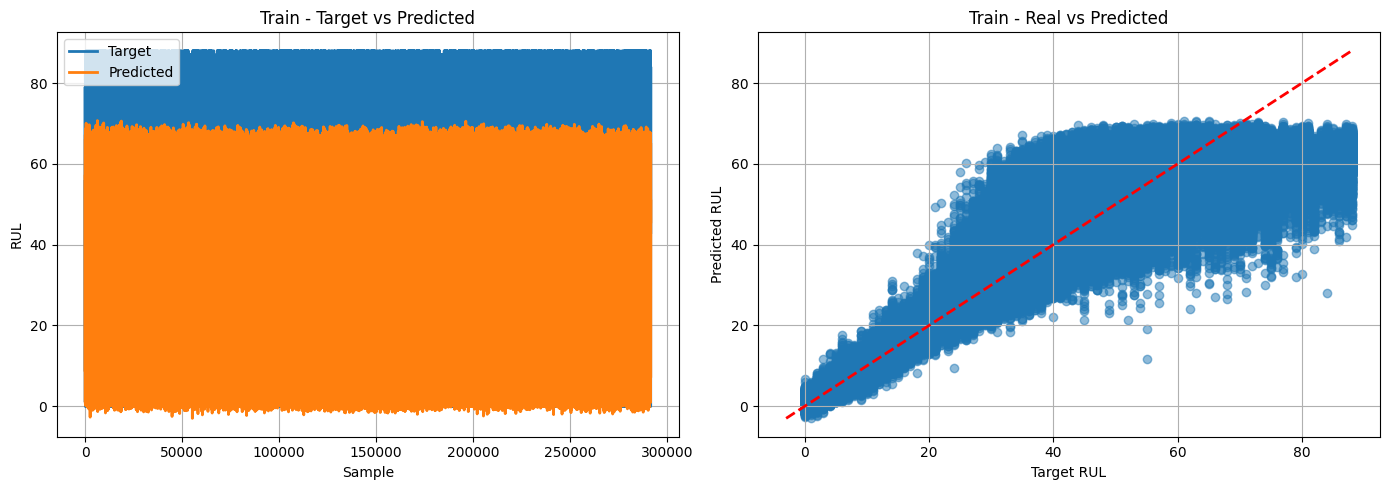

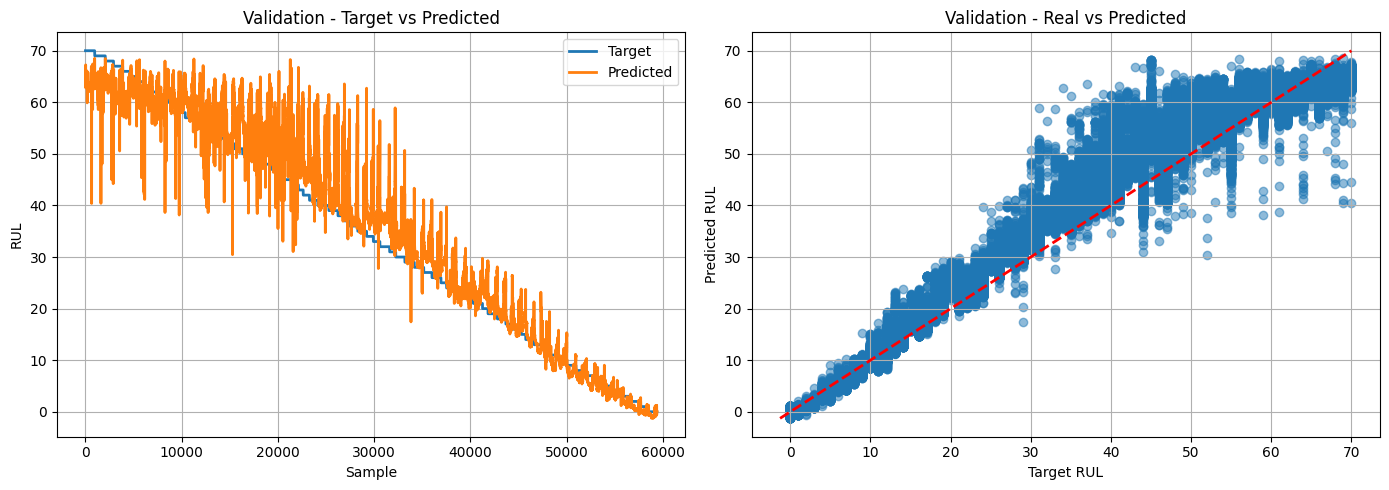

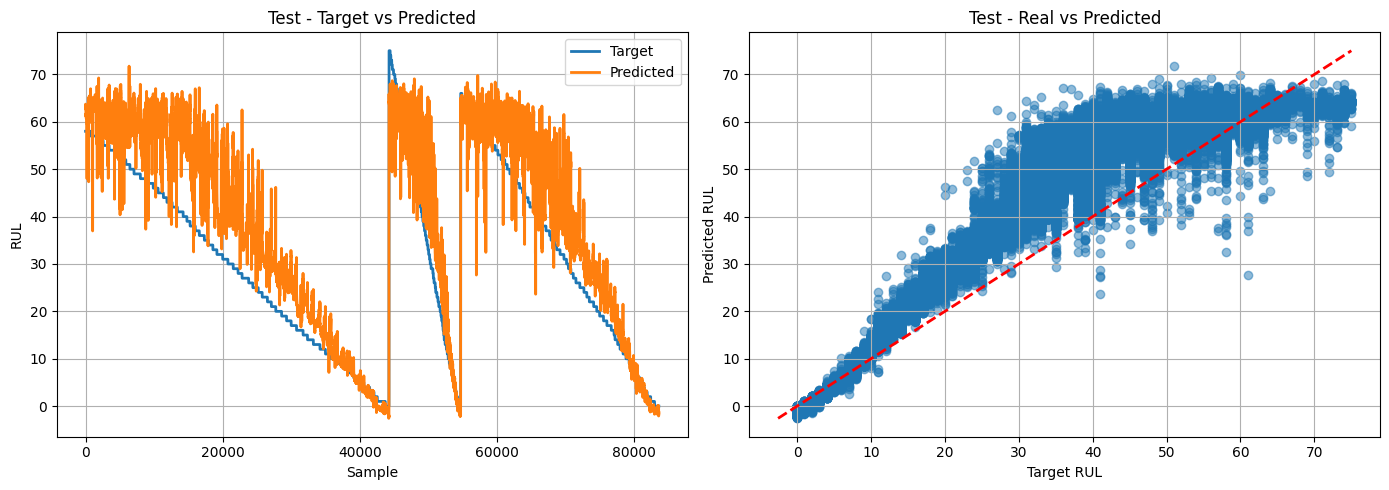

In [ ]:
search_space = [
    {"lr": 1e-3, "dropout": 0.1, "d_model": 64},
    {"lr": 5e-4, "dropout": 0.2, "d_model": 64},
    {"lr": 1e-4, "dropout": 0.3, "d_model": 32},
]

best_val_rmse = float("inf")
best_config = None

for config in search_space:
    model = FirstBaseline(
        num_features=len(features),
        d_model=config["d_model"],
        dropout=config["dropout"]
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=config["lr"],
        weight_decay=1e-4
    )

    print(f'Configuration: lr: {config["lr"]}, dropout: {config["dropout"]}, dimensionality of the model: {config["d_model"]}')

    trained_model, train_preds, train_targets, val_preds, val_targets = train(
    criterion, optimizer, train_loader, val_loader, model, num_epochs=20
    )

    test_loss, test_rmse, test_nasa, test_preds, test_targets = test(trained_model, test_loader, criterion)
    # evaluate val RMSE here and compare
    plot_predictions(train_targets, train_preds, split_name="Train")
    plot_predictions(val_targets, val_preds, split_name="Validation")
    plot_predictions(test_targets, test_preds, split_name="Test")

## **Optuna parameters tunning**

#### **physical sensors only**

In [ ]:
!pip install optuna

In [ ]:
import optuna



def objective(trial):
    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
    
    d_model = trial.suggest_categorical("d_model", [32, 64, 128])
    nhead = trial.suggest_categorical("nhead", [2, 4, 8])

    if d_model % nhead != 0:
        raise optuna.TrialPruned()

    num_layers = trial.suggest_int("num_layers", 1, 3)
    dropout = trial.suggest_float("dropout", 0.1, 0.5)
    dim_feedforward = trial.suggest_categorical("dim_feedforward", [64, 128, 256])
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])
    num_epochs = trial.suggest_int("num_epochs", 10, 40)
    window_size = trial.suggest_categorical("window_size", [50, 100, 500])
    stride = trial.suggest_categorical("stride", [15, 20, 30, 40, 150, 200])

    valid_strides = {
        50: [15, 20],
        100: [30, 40],
        500: [150, 200]
    }

    if stride not in valid_strides[window_size]:
        raise optuna.TrialPruned()

    train_engine_df = X_train_scaled_df[X_train_scaled_df['unit'] != 18]
    val_engine_df   = X_train_scaled_df[X_train_scaled_df['unit'] == 18]

    print(f"Shape of train_engine_df: {train_engine_df.shape} and engine units: {train_engine_df['unit'].unique()}")
    print(f"Shape of val_engine_df: {val_engine_df.shape} and engine units: {val_engine_df['unit'].unique()}")
    print(f"Shape of X_test_scaled_df: {X_test_scaled_df.shape} and engine units: {X_test_scaled_df['unit'].unique()}")

    X_windows_train, Y_windows_train = create_windows(train_engine_df, features, window_size=window_size, stride=stride)
    X_windows_val, Y_windows_val     = create_windows(val_engine_df, features, window_size=window_size, stride=stride)
    X_windows_test, Y_windows_test = create_windows(X_test_scaled_df, features, window_size=window_size, stride=stride)

    print("X train normalized windows shape:",X_windows_train.shape,"\n Y train windows  shape:" , Y_windows_train.shape) 
    print("X val windows shape:",X_windows_val.shape,"\n Y val windows  shape:" , Y_windows_val.shape) # engine (18) for validating
    print("X test windows shape:",X_windows_test.shape,"\n Y test windows  shape:" , Y_windows_test.shape) 

    dataset_train = CMAPSS(X_windows_train, Y_windows_train)
    dataset_val   = CMAPSS(X_windows_val, Y_windows_val)
    dataset_test  = CMAPSS(X_windows_test, Y_windows_test)

    train_loader = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(dataset_val, batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(dataset_test, batch_size=batch_size, shuffle=False)

    model = FirstBaseline(
        num_features=len(features),
        d_model=d_model,
        nhead=nhead,
        num_layers=num_layers,
        dim_feedforward=dim_feedforward,
        dropout=dropout
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    criterion = torch.nn.MSELoss()

    model, train_preds, train_targets, val_preds, val_targets = train(
        criterion=criterion,
        optimizer=optimizer,
        train_loader=train_loader,
        val_loader=val_loader,
        model=model,
        num_epochs=num_epochs
    )

    test_loss, test_rmse, test_nasa, test_preds, test_targets = test(model, test_loader, criterion)  # or val NASA score
    

    return test_nasa


study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30)

print(study.best_params)
print(study.best_value)

[I 2026-07-12 11:40:56,572] A new study created in memory with name: no-name-4073497d-a7dc-4d58-89cc-808b8cba12ab


Shape of train_engine_df: (4372728, 21) and engine units: [ 2  5 10 16 20]
Shape of val_engine_df: (890719, 21) and engine units: [18]
Shape of X_test_scaled_df: (1253743, 21) and engine units: [11 14 15]
X train normalized windows shape: (145744, 100, 18) 
 Y train windows  shape: (145744,)
X val windows shape: (29688, 100, 18) 
 Y val windows  shape: (29688,)
X test windows shape: (41783, 100, 18) 
 Y test windows  shape: (41783,)
cuda
cuda:0
Epoch 1/26 - LR: 0.000016 - Train Loss: 1831.9143 - Train RMSE: 42.8009 - Train NASA mean: 60.5686 - Train NASA total: 8827504.61 - Val Loss: 1432.2753 - Val RMSE: 37.8454 - Val NASA mean: 32.2654 - Val NASA total: 957895.20
Epoch 2/26 - LR: 0.000016 - Train Loss: 1668.3614 - Train RMSE: 40.8456 - Train NASA mean: 50.5239 - Train NASA total: 7363561.94 - Val Loss: 1272.0510 - Val RMSE: 35.6658 - Val NASA mean: 26.1820 - Val NASA total: 777292.00
Epoch 3/26 - LR: 0.000016 - Train Loss: 1467.3007 - Train RMSE: 38.3054 - Train NASA mean: 39.6792 - 

[I 2026-07-12 11:43:40,626] Trial 0 finished with value: 7.178356693248786 and parameters: {'lr': 1.5636891600917273e-05, 'd_model': 64, 'nhead': 4, 'num_layers': 3, 'dropout': 0.16446833760867507, 'dim_feedforward': 64, 'weight_decay': 7.932275420967714e-06, 'batch_size': 128, 'num_epochs': 26, 'window_size': 100, 'stride': 30}. Best is trial 0 with value: 7.178356693248786.
[I 2026-07-12 11:43:40,633] Trial 1 pruned. 


Test Loss: 390.8390 - Test RMSE: 19.7696 - Test NASA mean: 7.1784 - Test NASA total: 299933.28
Shape of train_engine_df: (4372728, 21) and engine units: [ 2  5 10 16 20]
Shape of val_engine_df: (890719, 21) and engine units: [18]
Shape of X_test_scaled_df: (1253743, 21) and engine units: [11 14 15]
X train normalized windows shape: (145744, 100, 18) 
 Y train windows  shape: (145744,)
X val windows shape: (29688, 100, 18) 
 Y val windows  shape: (29688,)
X test windows shape: (41783, 100, 18) 
 Y test windows  shape: (41783,)
cuda
cuda:0
Epoch 1/35 - LR: 0.000924 - Train Loss: 550.9531 - Train RMSE: 23.4724 - Train NASA mean: 9.9611 - Train NASA total: 1451776.46 - Val Loss: 468.7445 - Val RMSE: 21.6505 - Val NASA mean: 9.5420 - Val NASA total: 283283.89
Epoch 2/35 - LR: 0.000924 - Train Loss: 512.3670 - Train RMSE: 22.6355 - Train NASA mean: 8.5699 - Train NASA total: 1249012.60 - Val Loss: 531.1109 - Val RMSE: 23.0458 - Val NASA mean: 13.2925 - Val NASA total: 394626.81
Epoch 3/35 - 

[I 2026-07-12 11:46:14,146] Trial 2 finished with value: 14.061708550947564 and parameters: {'lr': 0.000923861057566201, 'd_model': 32, 'nhead': 4, 'num_layers': 2, 'dropout': 0.44203405214491065, 'dim_feedforward': 128, 'weight_decay': 0.0005768759413291965, 'batch_size': 32, 'num_epochs': 35, 'window_size': 100, 'stride': 30}. Best is trial 0 with value: 7.178356693248786.
[I 2026-07-12 11:46:14,148] Trial 3 pruned. 
[I 2026-07-12 11:46:14,150] Trial 4 pruned. 
[I 2026-07-12 11:46:14,151] Trial 5 pruned. 
[I 2026-07-12 11:46:14,152] Trial 6 pruned. 
[I 2026-07-12 11:46:14,152] Trial 7 pruned. 


...

Shape of train_engine_df: (4372728, 21) and engine units: [ 2  5 10 16 20]
Shape of val_engine_df: (890719, 21) and engine units: [18]
Shape of X_test_scaled_df: (1253743, 21) and engine units: [11 14 15]
X train normalized windows shape: (218627, 50, 18) 
 Y train windows  shape: (218627,)
X val windows shape: (44534, 50, 18) 
 Y val windows  shape: (44534,)
X test windows shape: (62682, 50, 18) 
 Y test windows  shape: (62682,)
cuda
cuda:0
Epoch 1/13 - LR: 0.000046 - Train Loss: 774.5206 - Train RMSE: 27.8302 - Train NASA mean: 16.7318 - Train NASA total: 3658015.70 - Val Loss: 443.2843 - Val RMSE: 21.0543 - Val NASA mean: 7.7874 - Val NASA total: 346802.07
Epoch 2/13 - LR: 0.000046 - Train Loss: 510.6571 - Train RMSE: 22.5977 - Train NASA mean: 8.4897 - Train NASA total: 1856084.48 - Val Loss: 453.6996 - Val RMSE: 21.3002 - Val NASA mean: 8.5496 - Val NASA total: 380747.53
Epoch 3/13 - LR: 0.000046 - Train Loss: 194.6577 - Train RMSE: 13.9520 - Train NASA mean: 2.7421 - Train NASA t

[I 2026-07-12 13:20:08,579] Trial 24 finished with value: 0.4901833787637962 and parameters: {'lr': 4.646806456018414e-05, 'd_model': 64, 'nhead': 2, 'num_layers': 3, 'dropout': 0.1040272585943322, 'dim_feedforward': 128, 'weight_decay': 4.150884440062123e-06, 'batch_size': 32, 'num_epochs': 13, 'window_size': 50, 'stride': 20}. Best is trial 24 with value: 0.4901833787637962.


Test Loss: 33.0133 - Test RMSE: 5.7457 - Test NASA mean: 0.4902 - Test NASA total: 30725.67
Shape of train_engine_df: (4372728, 21) and engine units: [ 2  5 10 16 20]
Shape of val_engine_df: (890719, 21) and engine units: [18]
Shape of X_test_scaled_df: (1253743, 21) and engine units: [11 14 15]
X train normalized windows shape: (291501, 50, 18) 
 Y train windows  shape: (291501,)
X val windows shape: (59378, 50, 18) 
 Y val windows  shape: (59378,)
X test windows shape: (83574, 50, 18) 
 Y test windows  shape: (83574,)
cuda
cuda:0
Epoch 1/13 - LR: 0.000042 - Train Loss: 734.9068 - Train RMSE: 27.1092 - Train NASA mean: 15.7995 - Train NASA total: 4605582.45 - Val Loss: 442.7515 - Val RMSE: 21.0417 - Val NASA mean: 7.7501 - Val NASA total: 460186.68
Epoch 2/13 - LR: 0.000042 - Train Loss: 277.4732 - Train RMSE: 16.6575 - Train NASA mean: 4.1985 - Train NASA total: 1223878.76 - Val Loss: 38.5602 - Val RMSE: 6.2097 - Val NASA mean: 0.6144 - Val NASA total: 36483.18
Epoch 3/13 - LR: 0.000

[I 2026-07-12 13:28:54,676] Trial 25 finished with value: 1.9439055696274221 and parameters: {'lr': 4.15170530138069e-05, 'd_model': 64, 'nhead': 2, 'num_layers': 3, 'dropout': 0.11164446518144472, 'dim_feedforward': 128, 'weight_decay': 3.326362301493011e-06, 'batch_size': 32, 'num_epochs': 13, 'window_size': 50, 'stride': 15}. Best is trial 24 with value: 0.4901833787637962.
[I 2026-07-12 13:28:54,684] Trial 26 pruned. 
[I 2026-07-12 13:28:54,693] Trial 27 pruned. 
[I 2026-07-12 13:28:54,706] Trial 28 pruned. 
[I 2026-07-12 13:28:54,717] Trial 29 pruned. 


{'lr': 4.646806456018414e-05, 'd_model': 64, 'nhead': 2, 'num_layers': 3, 'dropout': 0.1040272585943322, 'dim_feedforward': 128, 'weight_decay': 4.150884440062123e-06, 'batch_size': 32, 'num_epochs': 13, 'window_size': 50, 'stride': 20}
0.4901833787637962


### **Best hyperparameters from Optuna**

In [ ]:
best_params = study.best_params
print(best_params)
print(study.best_value)

print ("=======================================================================================================")
print ("=======================================================================================================")

top3 = sorted(
    [t for t in study.trials if t.value is not None],
    key=lambda t: t.value
)[:3]

# get best three trials
for i, trial in enumerate(top3, 1):
    print(f"Top {i}: value={trial.value}")
    print(trial.params)


best_window_size = best_params["window_size"]
best_stride = best_params["stride"]
best_d_model = best_params["d_model"]
best_nhead = best_params["nhead"]
best_num_layers = best_params["num_layers"]
best_dropout = best_params["dropout"]
best_dim_feedforward = best_params["dim_feedforward"]
best_weight_decay = best_params["weight_decay"]
best_batch_size = best_params["batch_size"]
best_lr = best_params["lr"]
best_num_epochs = best_params["num_epochs"]

print(
    f"best_window_size: {best_window_size}\n"
    f"best_stride: {best_stride}\n"
    f"best_d_model: {best_d_model}\n"
    f"best_nhead: {best_nhead}\n"
    f"best_num_layers: {best_num_layers}\n"
    f"best_dropout: {best_dropout}\n"
    f"best_dim_feedforward: {best_dim_feedforward}\n"
    f"best_weight_decay: {best_weight_decay}\n"
    f"best_batch_size: {best_batch_size}\n"
    f"best_lr: {best_lr}\n"
    f"best_num_epochs: {best_num_epochs}"
)

{'lr': 4.646806456018414e-05, 'd_model': 64, 'nhead': 2, 'num_layers': 3, 'dropout': 0.1040272585943322, 'dim_feedforward': 128, 'weight_decay': 4.150884440062123e-06, 'batch_size': 32, 'num_epochs': 13, 'window_size': 50, 'stride': 20}
0.4901833787637962
Top 1: value=0.4901833787637962
{'lr': 4.646806456018414e-05, 'd_model': 64, 'nhead': 2, 'num_layers': 3, 'dropout': 0.1040272585943322, 'dim_feedforward': 128, 'weight_decay': 4.150884440062123e-06, 'batch_size': 32, 'num_epochs': 13, 'window_size': 50, 'stride': 20}
Top 2: value=0.5535609198993902
{'lr': 6.854964325007053e-05, 'd_model': 64, 'nhead': 2, 'num_layers': 1, 'dropout': 0.36129000782048987, 'dim_feedforward': 128, 'weight_decay': 4.504126042632754e-05, 'batch_size': 32, 'num_epochs': 11, 'window_size': 50, 'stride': 15}
Top 3: value=0.5878048510562521
{'lr': 0.00040533240559566616, 'd_model': 64, 'nhead': 2, 'num_layers': 2, 'dropout': 0.213881497959228, 'dim_feedforward': 128, 'weight_decay': 1.9384884346085842e-05, 'bat

## **Retrain with the best hyperparameters from Optuna**

Shape of train_engine_df: (4372728, 21) and engine units: [ 2  5 10 16 20]
Shape of val_engine_df: (890719, 21) and engine units: [18]
Shape of X_test_scaled_df: (1253743, 21) and engine units: [11 14 15]
X train normalized windows shape: (218627, 50, 18) 
 Y train windows  shape: (218627,)
X val windows shape: (44534, 50, 18) 
 Y val windows  shape: (44534,)
X test windows shape: (62682, 50, 18) 
 Y test windows  shape: (62682,)
cuda
cuda:0
Epoch 1/40 - LR: 0.000046 - Train Loss: 712.6737 - Train RMSE: 26.6959 - Train NASA mean: 14.6610 - Train NASA total: 3205293.50 - Val Loss: 445.9227 - Val RMSE: 21.1169 - Val NASA mean: 7.9841 - Val NASA total: 355564.51
Epoch 2/40 - LR: 0.000046 - Train Loss: 385.3154 - Train RMSE: 19.6295 - Train NASA mean: 6.1340 - Train NASA total: 1341059.82 - Val Loss: 104.7782 - Val RMSE: 10.2361 - Val NASA mean: 1.1529 - Val NASA total: 51344.12
Epoch 3/40 - LR: 0.000046 - Train Loss: 137.6602 - Train RMSE: 11.7329 - Train NASA mean: 1.8993 - Train NASA to

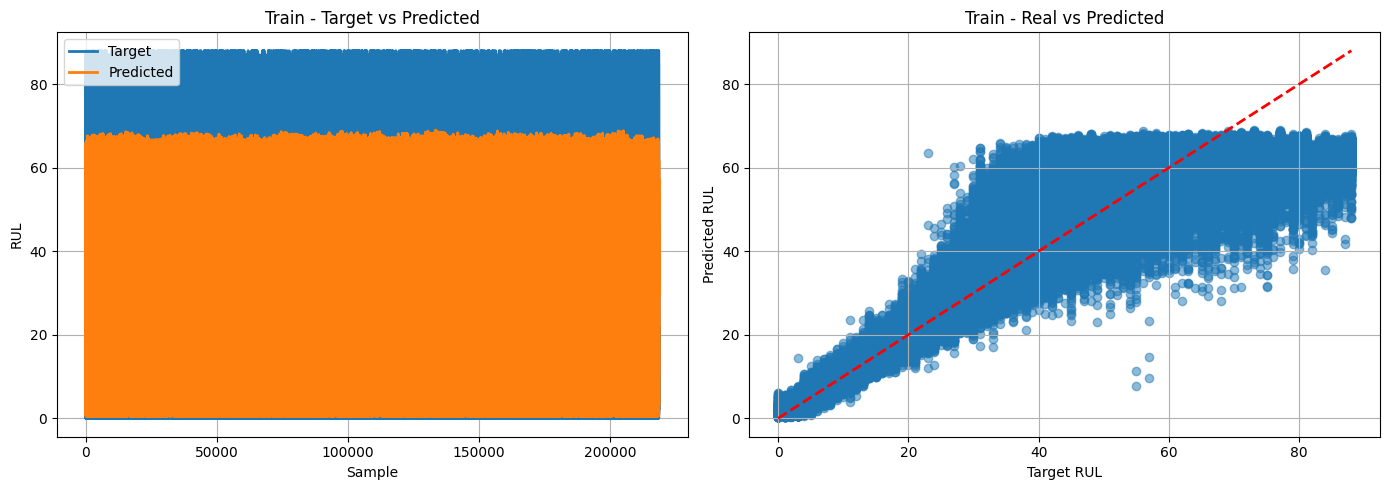

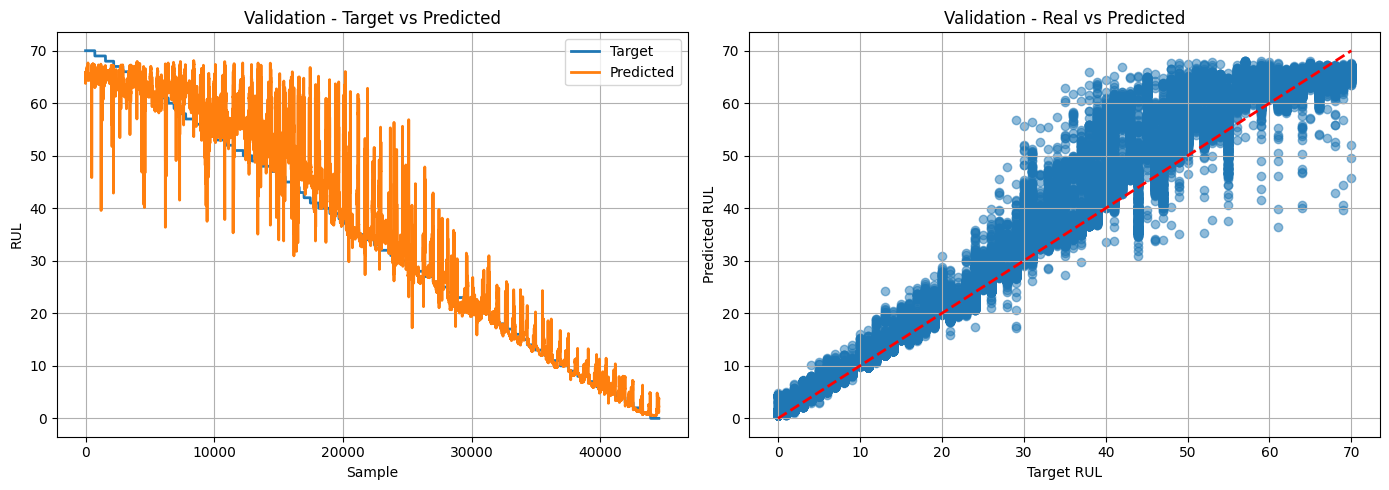

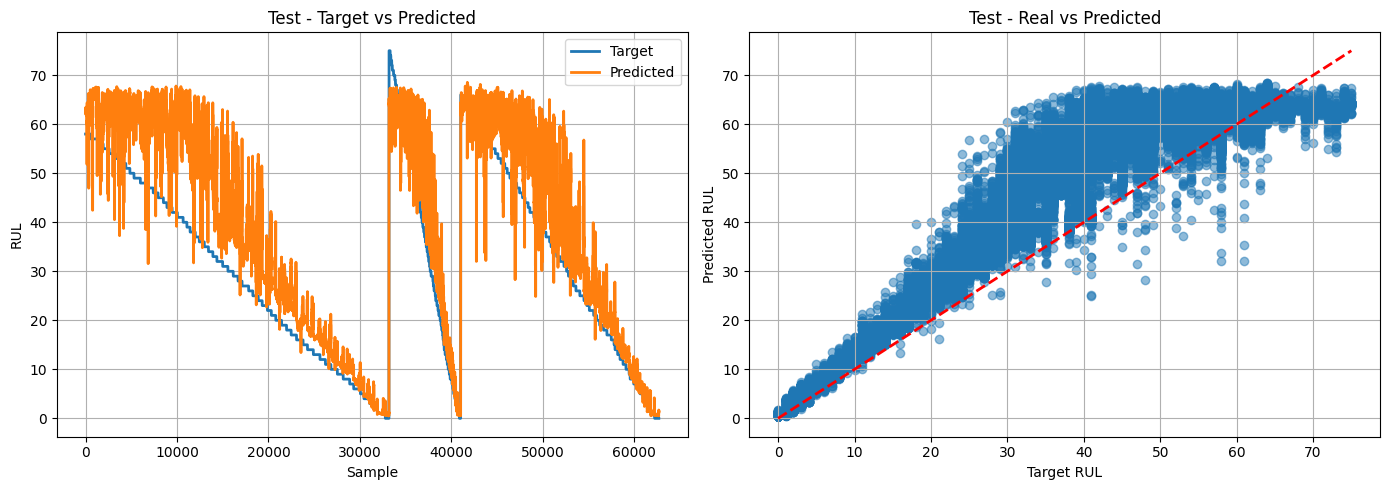

In [ ]:
train_engine_df = X_train_scaled_df[X_train_scaled_df['unit'] != 18]
val_engine_df   = X_train_scaled_df[X_train_scaled_df['unit'] == 18]

print(f"Shape of train_engine_df: {train_engine_df.shape} and engine units: {train_engine_df['unit'].unique()}")
print(f"Shape of val_engine_df: {val_engine_df.shape} and engine units: {val_engine_df['unit'].unique()}")
print(f"Shape of X_test_scaled_df: {X_test_scaled_df.shape} and engine units: {X_test_scaled_df['unit'].unique()}")

X_windows_train, Y_windows_train = create_windows(train_engine_df, features, window_size=best_window_size, stride=best_stride)
X_windows_val, Y_windows_val     = create_windows(val_engine_df, features, window_size=best_window_size, stride=best_stride)
X_windows_test, Y_windows_test = create_windows(X_test_scaled_df, features, window_size=best_window_size, stride=best_stride)

print("X train normalized windows shape:",X_windows_train.shape,"\n Y train windows  shape:" , Y_windows_train.shape) 
print("X val windows shape:",X_windows_val.shape,"\n Y val windows  shape:" , Y_windows_val.shape) # engine (18) for validating
print("X test windows shape:",X_windows_test.shape,"\n Y test windows  shape:" , Y_windows_test.shape) 

dataset_train = CMAPSS(X_windows_train, Y_windows_train)
dataset_val   = CMAPSS(X_windows_val, Y_windows_val)
dataset_test  = CMAPSS(X_windows_test, Y_windows_test)

train_loader = DataLoader(dataset_train, batch_size=best_batch_size, shuffle=True)
val_loader   = DataLoader(dataset_val, batch_size=best_batch_size, shuffle=False)
test_loader  = DataLoader(dataset_test, batch_size=best_batch_size, shuffle=False)

model = FirstBaseline(
    num_features=len(features),
    d_model=best_d_model,
    nhead=best_nhead,
    num_layers=best_num_layers,
    dim_feedforward=best_dim_feedforward,
    dropout=best_dropout
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=best_lr,
    weight_decay=best_weight_decay
)

criterion = torch.nn.MSELoss()

model, train_preds, train_targets, val_preds, val_targets = train(
    criterion=criterion,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=val_loader,
    model=model,
    num_epochs=40 
)

test_loss, test_rmse, test_nasa, test_preds, test_targets = test(model, test_loader, criterion)  # or val NASA score

plot_predictions(train_targets, train_preds, split_name="Train")
plot_predictions(val_targets, val_preds, split_name="Validation")
plot_predictions(test_targets, test_preds, split_name="Test")